# Assignment 2:

## Storyline: How Robbery Incidents Have Evolved in San Francisco (2009–2019)

## One time-series: Calendar plot 

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load the dataset
df = pd.read_csv('../Assignment-1/Data/SF_Crime_Data_Focus_Cleaned.csv', parse_dates=["Incident Date"])

# 🔹 Filter data for the period 2014-2024
df = df[(df["Incident Date"].dt.year >= 2009) & (df["Incident Date"].dt.year <= 2019)]



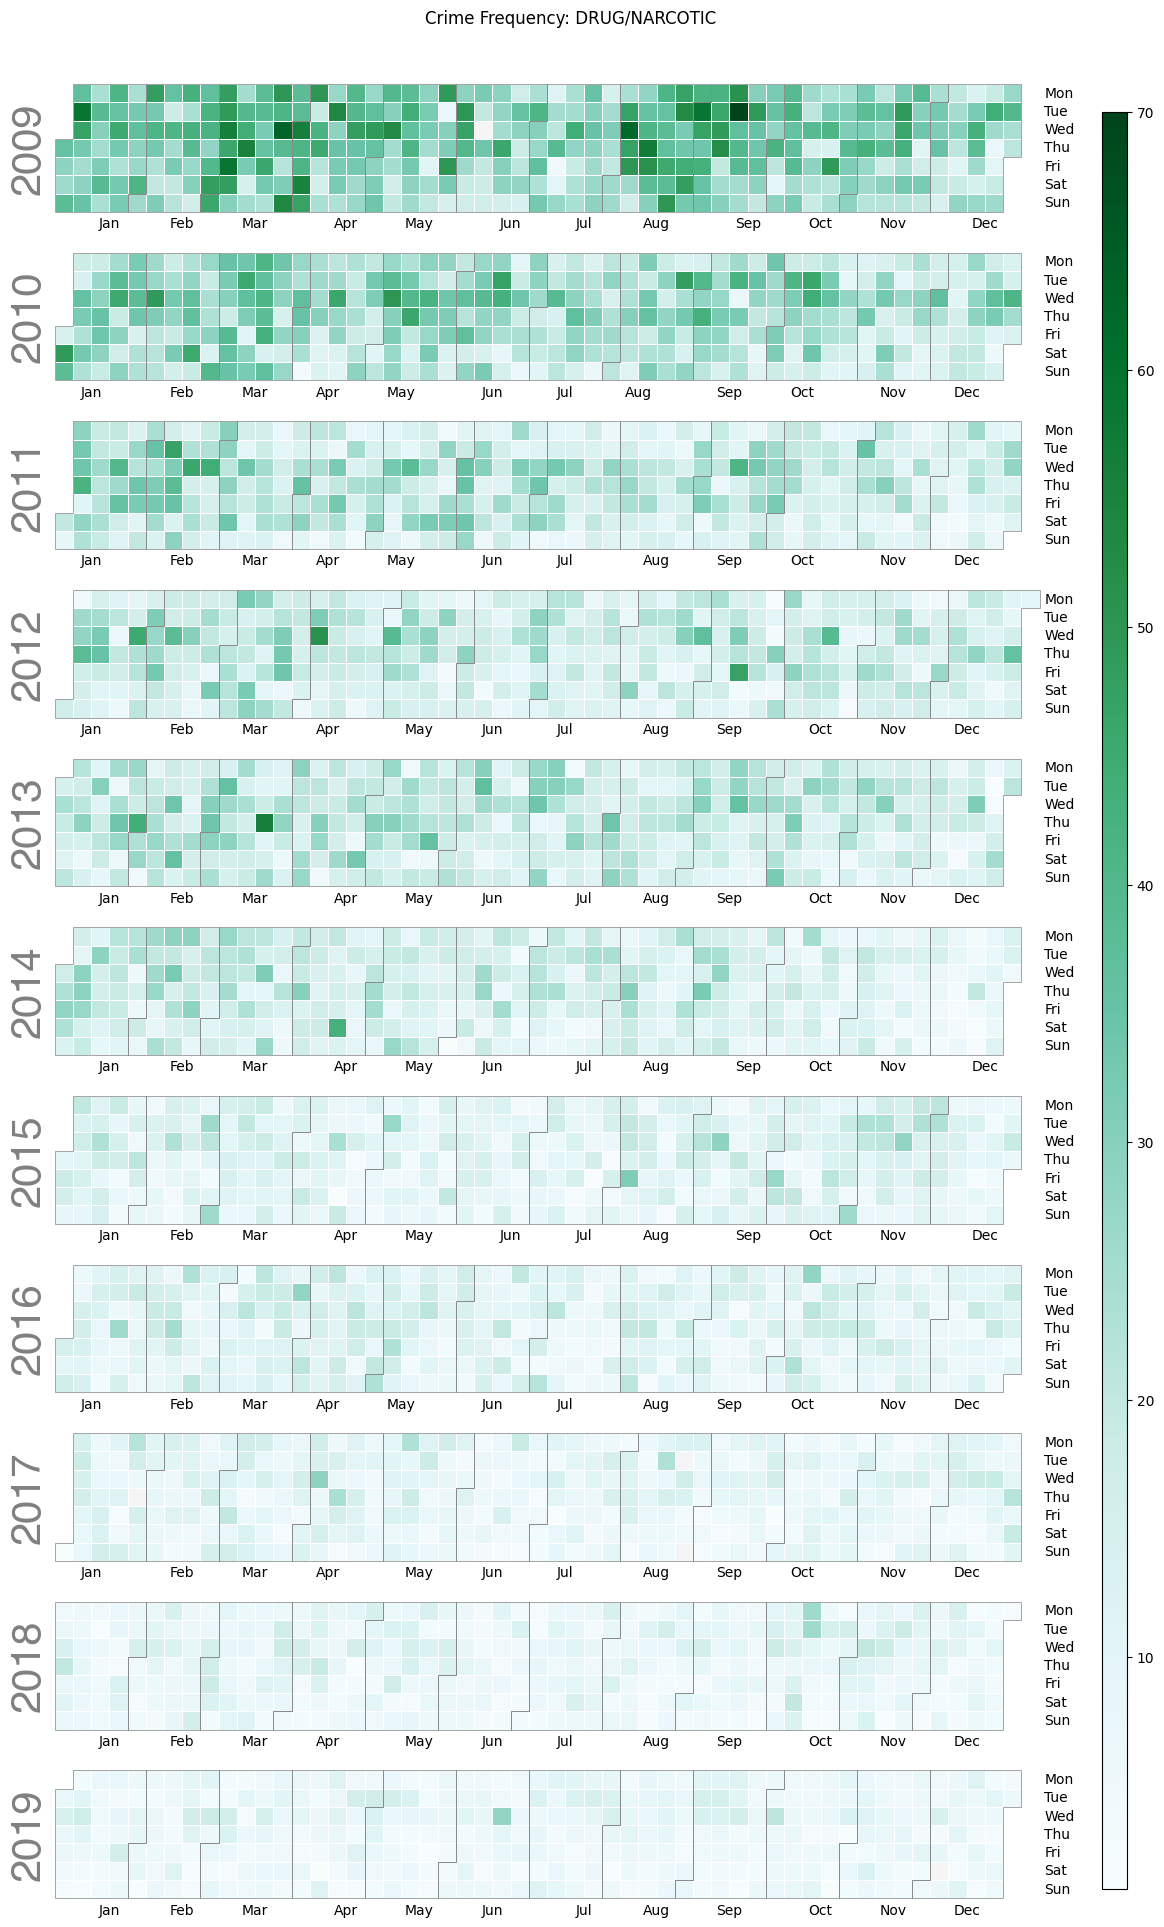

In [63]:
import calplot
crime_type = "DRUG/NARCOTIC" 

# 🔹 Aggregate daily counts
crime_daily = df[df["Incident Category"] == crime_type].groupby("Incident Date").size()

# 🔹 Plot calendar heatmap and save the figure
# Create the calendar plot
fig, axes = calplot.calplot(
    crime_daily, 
    cmap="BuGn", 
    colorbar=True, 
    suptitle=f"Crime Frequency: {crime_type}", 
    linewidth=0.5, 
    dropzero=True, 
    edgecolor="gray"
)

# Save the figure before showing it
fig.savefig("calendar_plot.png", dpi=300, bbox_inches='tight')


# 🔹 Then show
plt.show()



### Calendar Plot: Drug/Narcotic Crimes (2009–2019)

The calendar visualization above provides a detailed year-by-year overview of drug/narcotic-related incidents in San Francisco from 2009 to 2019. Each row corresponds to a calendar year, with individual squares representing single days. The color intensity indicates the frequency of incidents on that day — darker green signifies a higher number of reports.

What stands out immediately is the high density of dark green cells in 2009, especially concentrated in certain periods such as early spring and mid-summer. This suggests that drug-related crime was not only more prevalent but also more consistently reported throughout the calendar year.

As we move downward through the years, the green gradually fades. From around 2014 onward, the number of dark-colored cells drops significantly. By 2018–2019, the calendar is largely filled with pale or nearly white squares — a visual confirmation of the steady and substantial decline in drug/narcotic offenses over the decade.

This decline might reflect a combination of policy changes, shifts in law enforcement focus, or broader socioeconomic dynamics affecting drug use and policing in the city. While deeper analysis is needed to understand the causes, the pattern here clearly supports the conclusion that drug-related crime in SF decreased dramatically between 2009 and 2019.

---

Let me know if you'd like to expand this with context (e.g., news or policy changes), or translate it to a more casual or technical tone!

## One map: Heatmap over hotspots for drugs/narcotics in San Francisco

In [65]:
import folium
from folium.plugins import HeatMap

# 🔹 Filter Drug/Narcotic incidents
df_DrugsAndNarcotics = df[df["Incident Category"] == "DRUG/NARCOTIC"].copy()

# 🔹 Initialize the map centered on San Francisco
sf_map = folium.Map(location=[37.7749, -122.4194], zoom_start=12)

# 🔹 Extract coordinates into list format
heat_data = df_DrugsAndNarcotics[["Latitude", "Longitude"]].dropna().values.tolist()

# 🔹 Add HeatMap layer
HeatMap(heat_data, radius=10, blur=15, max_zoom=1).add_to(sf_map)

# 🔹 Add all police districts as labeled markers
district_labels = {
    "BAYVIEW": [37.7294, -122.3928],
    "CENTRAL": [37.7985, -122.4078],
    "INGLESIDE": [37.7210, -122.4478],
    "MISSION": [37.7599, -122.4148],
    "NORTHERN": [37.7866, -122.4376],
    "PARK": [37.7680, -122.4524],
    "RICHMOND": [37.7799, -122.4862],
    "SOUTHERN": [37.7786, -122.4059],
    "TARAVAL": [37.7433, -122.4750],
    "TENDERLOIN": [37.7831, -122.4170]
}

for name, coords in district_labels.items():
    folium.Marker(
        location=coords,
        popup=name.title(),
        icon=folium.Icon(color='darkblue')
    ).add_to(sf_map)

# 🔹 Show the map
sf_map

sf_map.save("interactive_map.html")



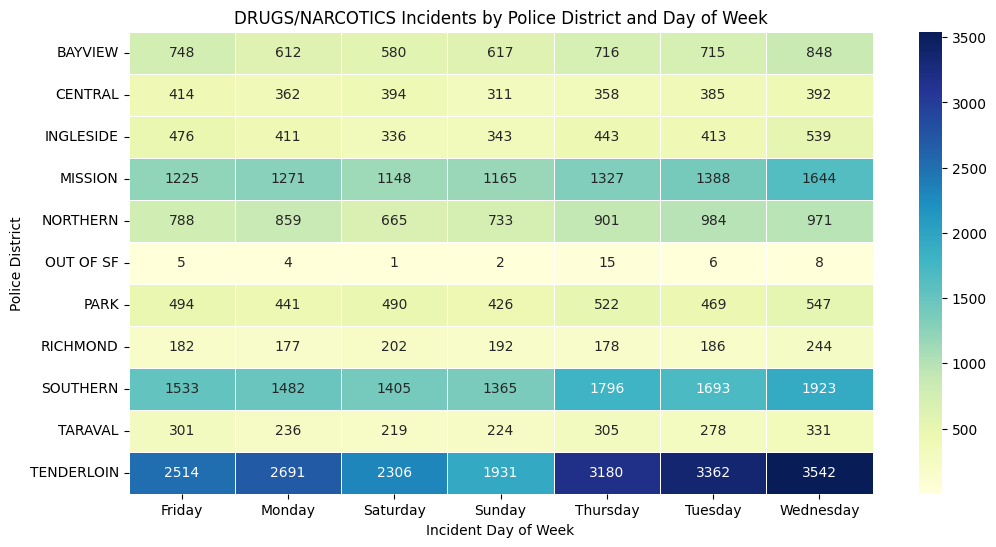

In [58]:
# Standardize all district names to uppercase
df_DrugsAndNarcotics['Police District'] = df_DrugsAndNarcotics['Police District'].str.upper()

pivot = df_DrugsAndNarcotics.pivot_table(index='Police District', columns='Incident Day of Week', aggfunc='size', fill_value=0)

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='d', linewidths=0.5)

plt.title('DRUGS/NARCOTICS Incidents by Police District and Day of Week')
plt.xlabel('Incident Day of Week')
plt.ylabel('Police District')
plt.show()
